In [69]:
%pip install rocketpy


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


# 미사일 궤적 데이터 생성

Monte Carlo 방식으로 미사일 비행 궤적 데이터를 생성하고 기종별 CSV 파일로 저장합니다.

In [70]:
# 외부 라이브러리
import warnings

import numpy as np
import pandas as pd
from rocketpy import Environment, Flight, Rocket, SolidMotor
from tqdm import tqdm

warnings.filterwarnings("ignore")

## 1. 시뮬레이션 설정

In [71]:
# 시뮬레이션 설정
NUM_SIMULATIONS_PER_MISSILE = 10
ENV_LATITUDE = 0.0
ENV_LONGITUDE = 0.0
ENV_ELEVATION = 0.0

MISSILE_TYPES = ["Khalij_Fars", "Qiam_1", "Zolfaghar", "Shahab_3"]
OUTPUT_FILE_TEMPLATE = "{}_10K_RealScale.csv"

## 2. 사용자 정의 대기 모델

In [72]:
# 사용자 정의 대기 모델
# RocketPy가 고도가 높아져도 압력과 온도를 계산할 수 있도록 단순 지수/선형 모델을 사용합니다.
def custom_pressure(altitude):
    altitude = np.asarray(altitude)
    return 101325.0 * np.exp(-altitude / 8420.0)


def custom_temperature(altitude):
    altitude = np.asarray(altitude)
    return np.where(altitude < 11000.0, 288.15 - 0.0065 * altitude, 216.65)

## 3. 미사일 모델 구성

In [73]:
# 기종별 기본 제원
MISSILE_SPECS = {
    "Khalij_Fars": {"radius": 0.305, "propellant_mass": 2200, "dry_mass": 1120, "burn_time": 25.0, "thrust": 200000},
    "Qiam_1": {"radius": 0.44, "propellant_mass": 4500, "dry_mass": 1655, "burn_time": 50.0, "thrust": 250000},
    "Zolfaghar": {"radius": 0.34, "propellant_mass": 3500, "dry_mass": 1120, "burn_time": 40.0, "thrust": 220000},
    "Shahab_3": {"radius": 0.625, "propellant_mass": 12000, "dry_mass": 3000, "burn_time": 70.0, "thrust": 450000},
}


def create_missile(missile_type, mass_variation, drag_variation):
    """변동값을 반영한 RocketPy 미사일 객체를 생성합니다."""
    spec = MISSILE_SPECS[missile_type]
    radius = spec["radius"]
    propellant_mass = spec["propellant_mass"] * mass_variation
    dry_mass = spec["dry_mass"] * mass_variation
    burn_time = spec["burn_time"]
    thrust_curve = [(0, spec["thrust"]), (burn_time, spec["thrust"])]

    grain_inner_radius = radius * 0.2
    grain_outer_radius = radius * 0.9
    grain_density = 1800
    grain_area = np.pi * (grain_outer_radius**2 - grain_inner_radius**2)
    grain_height = propellant_mass / (grain_density * grain_area)
    drag_coefficient = 0.3 * drag_variation

    motor = SolidMotor(
        thrust_source=thrust_curve,
        dry_mass=200.0,
        dry_inertia=(50, 50, 10),
        nozzle_radius=radius * 0.8,
        grain_number=1,
        grain_density=grain_density,
        grain_outer_radius=grain_outer_radius,
        grain_initial_inner_radius=grain_inner_radius,
        grain_initial_height=grain_height,
        grain_separation=0.0,
        grains_center_of_mass_position=grain_height / 2,
        center_of_dry_mass_position=1.0,
        coordinate_system_orientation="nozzle_to_combustion_chamber",
    )

    missile = Rocket(
        radius=radius,
        mass=dry_mass,
        inertia=(2000, 2000, 100),
        power_off_drag=drag_coefficient,
        power_on_drag=drag_coefficient,
        center_of_mass_without_motor=2.0,
        coordinate_system_orientation="tail_to_nose",
    )
    missile.add_motor(motor, position=0)
    missile.add_nose(length=radius * 3, kind="vonKarman", position=3.0)
    missile.add_trapezoidal_fins(
        n=4,
        span=radius * 1.5,
        root_chord=radius * 1.5,
        tip_chord=radius * 0.5,
        position=-1.0,
    )

    return missile, burn_time, drag_coefficient

## 4. 비행 시뮬레이션 및 데이터셋 생성

In [74]:
def simulate_flight(missile_type, sim_id):
    """무작위 조건으로 한 번 비행하고 시계열 데이터를 반환합니다."""
    elevation = np.random.uniform(60, 80)
    azimuth = np.random.uniform(0, 360)
    mass_variation = np.random.uniform(0.95, 1.05)
    drag_variation = np.random.uniform(0.90, 1.10)
    wind_u = np.random.normal(0, 10.0)
    wind_v = np.random.normal(0, 10.0)
    wind_speed = np.sqrt(wind_u**2 + wind_v**2)
    wind_direction = (np.degrees(np.arctan2(wind_v, wind_u)) + 360) % 360

    environment = Environment(
        latitude=ENV_LATITUDE,
        longitude=ENV_LONGITUDE,
        elevation=ENV_ELEVATION,
    )
    environment.set_atmospheric_model(
        type="custom_atmosphere",
        pressure=custom_pressure,
        temperature=custom_temperature,
        wind_u=wind_u,
        wind_v=wind_v,
    )

    missile, burn_time, drag_coefficient = create_missile(
        missile_type,
        mass_variation,
        drag_variation,
    )
    flight = Flight(
        rocket=missile,
        environment=environment,
        rail_length=10.0,
        inclination=elevation,
        heading=azimuth,
        max_time=1200,
        max_time_step=0.5,
    )

    target_x = flight.x(flight.t_final)
    target_y = flight.y(flight.t_final)
    target_time = flight.t_final
    if target_time < 60.0:
        return []

    time_steps = np.append(np.arange(1.0, target_time, 1.0), target_time)
    initial_propellant_mass = missile.motor.propellant_initial_mass
    total_dry_mass = missile.mass + missile.motor.dry_mass
    rows = []

    for time in time_steps:
        current_mass = total_dry_mass
        if time < burn_time:
            current_mass += initial_propellant_mass * (1 - time / burn_time)

        vx, vy, vz = flight.vx(time), flight.vy(time), flight.vz(time)
        speed = np.sqrt(vx**2 + vy**2 + vz**2)
        altitude = flight.z(time)

        # 시뮬레이션에 적용한 대기 모델에서 현재 고도의 날씨값을 계산합니다.
        weather_pressure = float(custom_pressure(altitude))
        weather_temperature = float(custom_temperature(altitude))
        weather_air_density = weather_pressure / (287.05 * weather_temperature)
        mach = speed / 340.3
        dynamic_pressure = 0.5 * weather_air_density * speed**2

        try:
            pitch = float(flight.inclination(time))
        except Exception:
            pitch = np.degrees(np.arcsin(vz / (speed + 1e-6)))

        try:
            yaw = float(flight.heading(time))
        except Exception:
            yaw = np.degrees(np.arctan2(vy, vx))

        rows.append({
            "sim_id": sim_id,
            "time_step": round(time, 2),
            "MC_mass_var": round(mass_variation, 3),
            "MC_drag_coeff": round(drag_coefficient, 3),
            # 시뮬레이션에 입력된 바람 조건
            "weather_wind_u": round(wind_u, 3),
            "weather_wind_v": round(wind_v, 3),
            "weather_wind_speed": round(wind_speed, 3),
            "weather_wind_direction_deg": round(wind_direction, 3),
            # 현재 고도에서 적용된 대기 상태
            "weather_pressure": round(weather_pressure, 3),
            "weather_temperature": round(weather_temperature, 3),
            "weather_air_density": round(weather_air_density, 6),
            "x": flight.x(time), "y": flight.y(time), "z": altitude,
            "vx": vx, "vy": vy, "vz": vz,
            "ax": flight.ax(time), "ay": flight.ay(time), "az": flight.az(time),
            "pitch": pitch, "yaw": yaw,
            "mach": mach, "dynamic_pressure": dynamic_pressure,
            # 기존 컬럼과의 호환성을 위해 유지합니다.
            "air_density": weather_air_density,
            "current_mass": round(current_mass, 2),
            "Target_X": target_x, "Target_Y": target_y, "Target_T": target_time,
        })

    return rows


def generate_dataset(missile_type):
    """한 기종의 유효한 시뮬레이션을 목표 개수만큼 생성합니다."""
    rows = []
    simulation_id = 1

    with tqdm(total=NUM_SIMULATIONS_PER_MISSILE, desc=missile_type) as progress:
        while simulation_id <= NUM_SIMULATIONS_PER_MISSILE:
            try:
                simulation_rows = simulate_flight(missile_type, simulation_id)
                if not simulation_rows:
                    continue
                rows.extend(simulation_rows)
                simulation_id += 1
                progress.update(1)
            except Exception:
                # 실패한 시뮬레이션은 카운트하지 않고 같은 번호로 재시도합니다.
                continue

    return pd.DataFrame(rows)

## 5. 기종별 CSV 저장

In [75]:
# 기종별 데이터 생성 및 CSV 저장
print(
    f"기종별 {NUM_SIMULATIONS_PER_MISSILE}개, "
    f"총 {len(MISSILE_TYPES) * NUM_SIMULATIONS_PER_MISSILE}개 시뮬레이션을 시작합니다.\n"
)

for missile_type in MISSILE_TYPES:
    print(f"[{missile_type}] 궤적 데이터 생성 중...")
    dataset = generate_dataset(missile_type)
    output_file = OUTPUT_FILE_TEMPLATE.format(missile_type)
    dataset.to_csv(output_file, index=False)
    print(f"저장 완료: {output_file} ({len(dataset):,}행)\n")

print("모든 미사일 궤적 데이터셋 생성이 완료되었습니다.")

기종별 10개, 총 40개 시뮬레이션을 시작합니다.

[Khalij_Fars] 궤적 데이터 생성 중...


Khalij_Fars: 100%|██████████| 10/10 [00:06<00:00,  1.50it/s]


저장 완료: Khalij_Fars_10K_RealScale.csv (3,149행)

[Qiam_1] 궤적 데이터 생성 중...


Qiam_1: 100%|██████████| 10/10 [00:09<00:00,  1.00it/s]


저장 완료: Qiam_1_10K_RealScale.csv (3,477행)

[Zolfaghar] 궤적 데이터 생성 중...


Zolfaghar: 100%|██████████| 10/10 [00:06<00:00,  1.58it/s]


저장 완료: Zolfaghar_10K_RealScale.csv (4,716행)

[Shahab_3] 궤적 데이터 생성 중...


Shahab_3: 100%|██████████| 10/10 [00:09<00:00,  1.10it/s]

저장 완료: Shahab_3_10K_RealScale.csv (3,440행)

모든 미사일 궤적 데이터셋 생성이 완료되었습니다.


# 데이터셋 설명

## 연구 목적

이 노트북은 RocketPy 기반의 3차원 Monte Carlo 비행 시뮬레이션으로 미사일 궤적 합성 데이터를 생성합니다. 데이터는 초기 질량, 공기저항, 발사 방향, 바람 조건을 무작위로 변화시키며 생성되며, 각 시뮬레이션의 최종 탄착점과 비행시간을 예측 모델의 타깃으로 사용할 수 있습니다.

README에 정의된 대상 기종은 `Khalij_Fars`, `Qiam_1`, `Zolfaghar`, `Shahab_3`입니다. 각 CSV 파일은 한 기종의 여러 비행 시뮬레이션을 1초 간격의 시계열로 저장합니다. `sim_id`가 같은 행들이 하나의 비행 궤적을 구성합니다.

## 데이터 생성 조건

- 발사 고각: 60~80도
- 발사 방위각: 0~360도
- 초기 질량 변동: 기준값의 95~105%
- 공기저항 변동: 기준값의 90~110%
- 수평 바람: 동서 성분과 남북 성분을 평균 0, 표준편차 10 m/s의 정규분포로 생성
- 대기 모델: 고도에 따른 사용자 정의 압력·온도 모델
- 샘플링: 발사 후 1초 간격 및 최종 시각

## 컬럼 설명

| 컬럼 | 설명 | 단위 또는 형식 |
|---|---|---|
| `sim_id` | 하나의 비행 시뮬레이션을 식별하는 번호 | 정수 |
| `time_step` | 발사 후 경과 시간 | 초 |
| `MC_mass_var` | 해당 시뮬레이션의 초기 질량 변동 계수 | 배율 |
| `MC_drag_coeff` | 해당 시뮬레이션에 적용된 공기저항계수 | 무차원 |
| `weather_wind_u` | 시뮬레이션에 입력한 동서 방향 바람 성분 | m/s |
| `weather_wind_v` | 시뮬레이션에 입력한 남북 방향 바람 성분 | m/s |
| `weather_wind_speed` | 두 바람 성분으로 계산한 바람의 크기 | m/s |
| `weather_wind_direction_deg` | 바람 벡터의 방위각 | 도 |
| `weather_pressure` | 현재 고도에서 사용자 정의 대기 모델의 압력 | Pa |
| `weather_temperature` | 현재 고도에서 사용자 정의 대기 모델의 온도 | K |
| `weather_air_density` | 압력과 온도로 계산한 현재 고도의 공기 밀도 | kg/m³ |
| `x`, `y`, `z` | 발사 기준 좌표계에서의 위치 | m |
| `vx`, `vy`, `vz` | 각 좌표축 방향 속도 성분 | m/s |
| `ax`, `ay`, `az` | 각 좌표축 방향 가속도 성분 | m/s² |
| `pitch` | 비행체의 피치 각도 | 도 |
| `yaw` | 비행체의 요 각도 | 도 |
| `mach` | 현재 속도를 음속으로 나눈 마하수 | 무차원 |
| `dynamic_pressure` | 공기 밀도와 속도로 계산한 동압, $q = \frac{1}{2}\rho v^2$ | Pa |
| `air_density` | 기존 분석 코드와의 호환을 위해 저장한 공기 밀도 | kg/m³ |
| `current_mass` | 연료 소모를 반영한 현재 질량 | kg |
| `Target_X` | 해당 비행의 최종 탄착점 x 좌표 | m |
| `Target_Y` | 해당 비행의 최종 탄착점 y 좌표 | m |
| `Target_T` | 해당 비행의 최종 비행시간 | 초 |

`Target_X`, `Target_Y`, `Target_T`는 하나의 시뮬레이션에 속한 모든 시계열 행에서 동일합니다. 반면 위치, 속도, 가속도, 압력, 온도, 밀도는 `time_step`과 고도에 따라 변합니다.

## 파일 구성

- `Khalij_Fars_10K_RealScale.csv`
- `Qiam_1_10K_RealScale.csv`
- `Zolfaghar_10K_RealScale.csv`
- `Shahab_3_10K_RealScale.csv`

파일명은 기종을 나타내며, 각 행은 해당 기종의 특정 비행 시점에 대한 관측값입니다.

In [78]:
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib import font_manager

# 운영체제에 설치된 한글 폰트를 찾아 matplotlib 전체 그래프에 적용합니다.
korean_font_candidates = [
    "AppleGothic",
    "NanumGothic",
    "Malgun Gothic",
    "Noto Sans CJK KR",
]
available_fonts = {font.name for font in font_manager.fontManager.ttflist}
korean_font = next(
    (font for font in korean_font_candidates if font in available_fonts),
    None,
)
if korean_font is None:
    raise RuntimeError(
        "한글 폰트를 찾지 못했습니다. AppleGothic 또는 NanumGothic을 설치해 주세요."
    )

plt.rcParams["font.family"] = korean_font
plt.rcParams["axes.unicode_minus"] = False
print(f"matplotlib 한글 폰트: {korean_font}")

# 시각화에 필요한 컬럼만 읽어 메모리 사용량을 줄입니다.
trajectory_columns = [
    "sim_id",
    "time_step",
    "x",
    "y",
    "z",
    "weather_wind_speed",
    "weather_temperature",
    "weather_pressure",
    "weather_air_density",
    "Target_X",
    "Target_Y",
    "Target_T",
]

csv_files = sorted(Path(".").glob("*_10K_RealScale.csv"))
if not csv_files:
    raise FileNotFoundError("현재 폴더에서 *_10K_RealScale.csv 파일을 찾지 못했습니다.")

trajectory_frames = []
for csv_file in csv_files:
    frame = pd.read_csv(csv_file, usecols=trajectory_columns)
    frame["missile_type"] = csv_file.stem.replace("_10K_RealScale", "")
    trajectory_frames.append(frame)

trajectory_data = pd.concat(trajectory_frames, ignore_index=True)
trajectory_data.head()

matplotlib 한글 폰트: AppleGothic


,sim_id,time_step,weather_wind_speed,weather_pressure,weather_temperature,weather_air_density,x,y,z,Target_X,Target_Y,Target_T,missile_type
0,1,1.0,8.77,101065.636,288.010,1.222472,-8.729280,3.633844,21.580526,-252268.449796,47068.596634,261.488321,Khalij_Fars
1,1,2.0,8.77,100294.474,287.591,1.214912,-37.731457,15.310194,86.074057,-252268.449796,47068.596634,261.488321,Khalij_Fars
2,1,3.0,8.77,99027.121,286.895,1.202470,-91.654062,33.269022,193.149818,-252268.449796,47068.596634,261.488321,Khalij_Fars
3,1,4.0,8.77,97305.043,285.934,1.185527,-177.310721,55.497781,340.861402,-252268.449796,47068.596634,261.488321,Khalij_Fars
4,1,5.0,8.77,95145.125,284.706,1.164213,-295.913762,84.074059,529.869058,-252268.449796,47068.596634,261.488321,Khalij_Fars


In [81]:
# 시각화용 공통 전처리
terminal_data = (
    trajectory_data.sort_values("time_step")
    .groupby(["missile_type", "sim_id"], as_index=False)
    .tail(1)
    .copy()
)
terminal_data["target_distance"] = np.sqrt(
    terminal_data["Target_X"] ** 2 + terminal_data["Target_Y"] ** 2
)

weather_sample = trajectory_data.sample(
    n=min(10000, len(trajectory_data)),
    random_state=42,
).sort_values("z")

print(f"전체 행 수: {len(trajectory_data):,}")
print(f"전체 비행 수: {len(terminal_data):,}")
terminal_data.head()

전체 행 수: 14,782
전체 비행 수: 40


,sim_id,time_step,weather_wind_speed,weather_pressure,weather_temperature,weather_air_density,x,y,z,Target_X,Target_Y,Target_T,missile_type,target_distance
9946,9,93.62,8.668,101325.000,288.15,1.225012,-13288.470903,90380.080890,3.701870e-07,-13288.470903,90380.080890,93.624742,Shahab_3,91351.751382
8144,4,117.32,21.757,101325.000,288.15,1.225012,80113.098938,-69533.491141,8.234400e-06,80113.098938,-69533.491141,117.323907,Shahab_3,106080.229127
10065,10,118.38,9.345,101325.000,288.15,1.225012,81407.725211,-81518.764795,5.959136e-07,81407.725211,-81518.764795,118.382155,Shahab_3,115206.452674
9852,8,128.50,13.186,101325.000,288.15,1.225012,117896.159464,36158.946855,1.004188e-06,117896.159464,36158.946855,128.501799,Shahab_3,123316.559529
4418,4,175.58,10.794,101324.999,288.15,1.225012,-135614.352902,-152938.260965,7.431269e-05,-135614.352902,-152938.260965,175.578786,Qiam_1,204404.903024


## 시각화 1. 대표 3D 비행 궤적

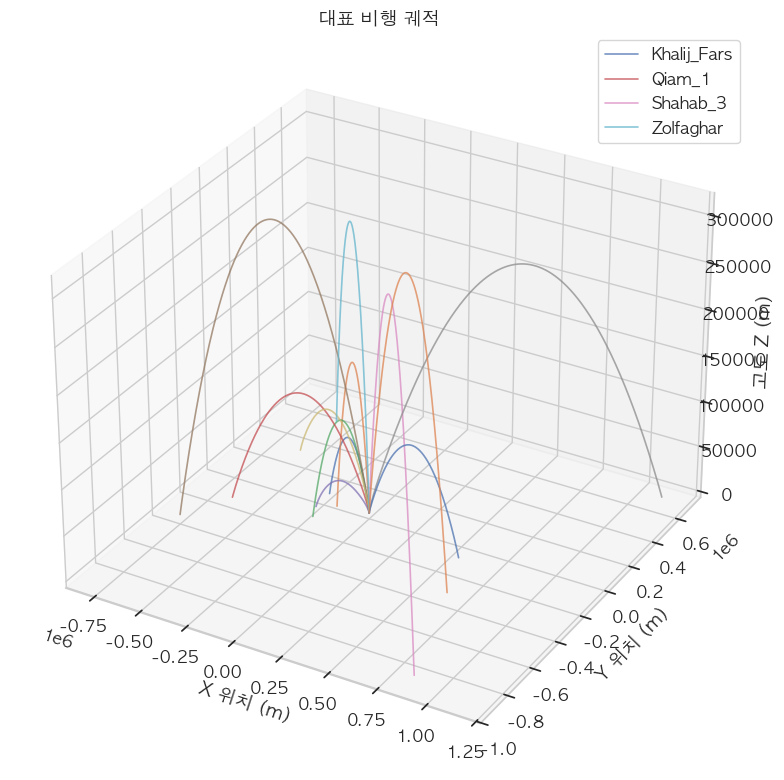

In [82]:
# 1. 기종별 대표 3D 비행 궤적
fig = plt.figure(figsize=(10, 8))
ax_trajectory = fig.add_subplot(111, projection="3d")

for missile_type, missile_data in trajectory_data.groupby("missile_type"):
    for sim_id, flight_data in missile_data.groupby("sim_id"):
        if sim_id > 3:
            continue
        ax_trajectory.plot(
            flight_data["x"],
            flight_data["y"],
            flight_data["z"],
            linewidth=1.2,
            alpha=0.75,
            label=missile_type if sim_id == 1 else None,
        )

ax_trajectory.set_title("대표 비행 궤적")
ax_trajectory.set_xlabel("X 위치 (m)")
ax_trajectory.set_ylabel("Y 위치 (m)")
ax_trajectory.set_zlabel("고도 Z (m)")
ax_trajectory.legend()
fig.tight_layout()
plt.show()

## 시각화 2. 풍속별 최종 탄착점

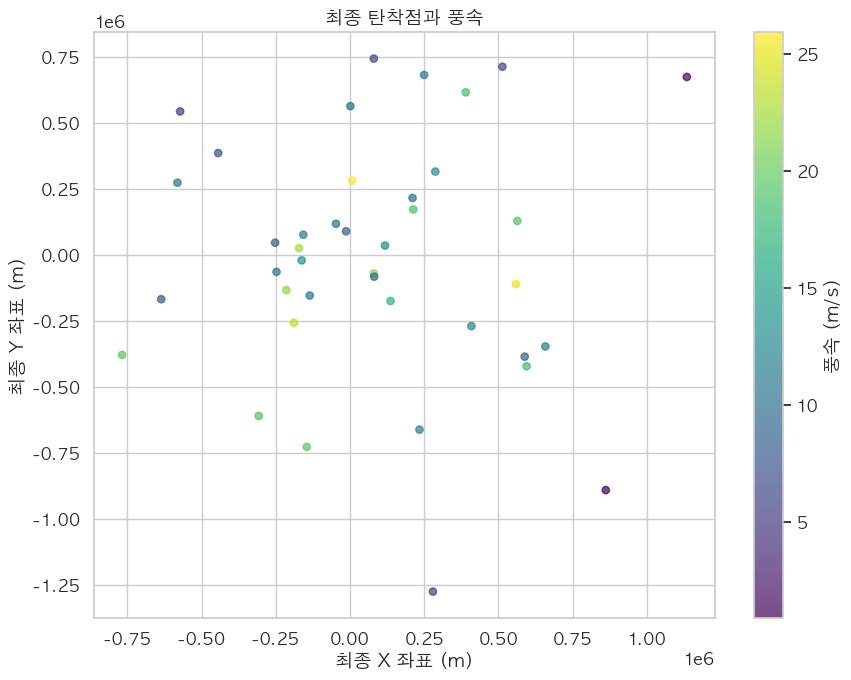

In [83]:
# 2. 풍속에 따른 최종 탄착점 분포
fig, ax_target = plt.subplots(figsize=(9, 7))

scatter = ax_target.scatter(
    terminal_data["Target_X"],
    terminal_data["Target_Y"],
    c=terminal_data["weather_wind_speed"],
    cmap="viridis",
    alpha=0.7,
    s=28,
)

ax_target.set_title("최종 탄착점과 풍속")
ax_target.set_xlabel("최종 X 좌표 (m)")
ax_target.set_ylabel("최종 Y 좌표 (m)")
colorbar = fig.colorbar(scatter, ax=ax_target)
colorbar.set_label("풍속 (m/s)")
fig.tight_layout()
plt.show()

## 시각화 3. 풍속과 최종 수평거리

In [ ]:
# 3. 풍속과 최종 수평거리의 관계
fig, ax_range = plt.subplots(figsize=(9, 7))

for missile_type, missile_data in terminal_data.groupby("missile_type"):
    ax_range.scatter(
        missile_data["weather_wind_speed"],
        missile_data["target_distance"],
        alpha=0.65,
        s=28,
        label=missile_type,
    )

ax_range.set_title("풍속과 최종 수평거리")
ax_range.set_xlabel("풍속 (m/s)")
ax_range.set_ylabel("최종 수평거리 (m)")
ax_range.legend()
fig.tight_layout()
plt.show()

## 시각화 4. 고도별 대기 온도와 압력

In [ ]:
# 4. 고도에 따른 대기 온도와 압력
fig, ax_temperature = plt.subplots(figsize=(10, 7))

ax_temperature.scatter(
    weather_sample["z"],
    weather_sample["weather_temperature"],
    s=6,
    alpha=0.25,
    color="tab:red",
)
ax_temperature.set_title("고도별 대기 상태")
ax_temperature.set_xlabel("고도 Z (m)")
ax_temperature.set_ylabel("온도 (K)", color="tab:red")
ax_temperature.tick_params(axis="y", labelcolor="tab:red")

ax_pressure = ax_temperature.twinx()
ax_pressure.scatter(
    weather_sample["z"],
    weather_sample["weather_pressure"],
    s=6,
    alpha=0.25,
    color="tab:blue",
)
ax_pressure.set_ylabel("압력 (Pa)", color="tab:blue")
ax_pressure.tick_params(axis="y", labelcolor="tab:blue")

fig.tight_layout()
plt.show()